In [1]:
import json
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import numpy as np

# Set hatch linewidth to make patterns more visible
mpl.rcParams['hatch.linewidth'] = 2.0

# Font size control
FONTSIZE = 28

# System colors and hatches (consistent across all figures)
SYSTEM_STYLE = {
    'ShuntServe': {'color': '#3498db', 'hatch': '/'},
    'HexGen':     {'color': '#1abc9c', 'hatch': '\\'},
    'AlpaServe':  {'color': '#e91e63', 'hatch': 'x'},
    'vLLM':       {'color': '#9b59b6', 'hatch': '+'},
}

RESULTS_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.'
print(f'Results dir: {os.path.abspath(RESULTS_DIR)}')

Results dir: /home/ubuntu/ShuntServe/ArtifactEvaluation/ModelPlacement/per_pipeline/qwen3-32b/results


In [2]:
# Load all predicted results
predicted_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'predicted_*.json')))

all_pipelines = []  # list of {label, system, predicted_throughput_rps}
system_totals = {}  # system -> total throughput

for fpath in predicted_files:
    with open(fpath) as f:
        data = json.load(f)
    for p in data['pipelines']:
        entry = {
            'label': p['label'],
            'system': p['system'],
            'predicted': p['predicted_throughput_rps'],
        }
        all_pipelines.append(entry)
        system_totals[p['system']] = system_totals.get(p['system'], 0) + p['predicted_throughput_rps']

# Sort pipelines by system order, then pipeline label
system_order = ['ShuntServe', 'HexGen', 'AlpaServe', 'vLLM']
all_pipelines.sort(key=lambda x: (system_order.index(x['system']), x['label']))

print(f'Loaded {len(all_pipelines)} pipelines from {len(predicted_files)} files')
for p in all_pipelines:
    print(f"  {p['label']:8s} ({p['system']:12s}): {p['predicted']:.4f} req/s")
print()
for sys in system_order:
    print(f"  {sys:12s} total: {system_totals.get(sys, 0):.4f} req/s")

Loaded 17 pipelines from 4 files
  SS-P1    (ShuntServe  ): 12.8827 req/s
  SS-P2    (ShuntServe  ): 7.6760 req/s
  SS-P3    (ShuntServe  ): 2.2446 req/s
  SS-P4    (ShuntServe  ): 2.2446 req/s
  HX-P1    (HexGen      ): 10.2581 req/s
  HX-P2    (HexGen      ): 5.1794 req/s
  HX-P3    (HexGen      ): 5.2189 req/s
  AP-P1    (AlpaServe   ): 1.4312 req/s
  AP-P2    (AlpaServe   ): 1.4312 req/s
  AP-P3    (AlpaServe   ): 1.4312 req/s
  AP-P4    (AlpaServe   ): 1.7153 req/s
  AP-P5    (AlpaServe   ): 1.7153 req/s
  AP-P6    (AlpaServe   ): 1.8442 req/s
  AP-P7    (AlpaServe   ): 1.8442 req/s
  vL-P1    (vLLM        ): 5.8980 req/s
  vL-P2    (vLLM        ): 3.9013 req/s
  vL-P3    (vLLM        ): 9.0036 req/s

  ShuntServe   total: 25.0478 req/s
  HexGen       total: 20.6565 req/s
  AlpaServe    total: 11.4125 req/s
  vLLM         total: 18.8029 req/s


In [3]:
# Load measured results (if available)
measured_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'measured_*.json')))

measured_map = {}  # label -> throughput
for fpath in measured_files:
    with open(fpath) as f:
        data = json.load(f)
    # Expected format: {"label": "SS-P1", "measured_throughput_rps": ...}
    # or pipeline_ranking benchmark output format
    if 'pipelines' in data:
        for p in data['pipelines']:
            measured_map[p['label']] = p.get('measured_throughput_rps', None)
    elif 'label' in data:
        measured_map[data['label']] = data.get('measured_throughput_rps', 
                                               data.get('throughput', None))

has_measured = len(measured_map) > 0
print(f'Measured data: {len(measured_map)} pipelines' if has_measured else 'No measured data yet')

No measured data yet


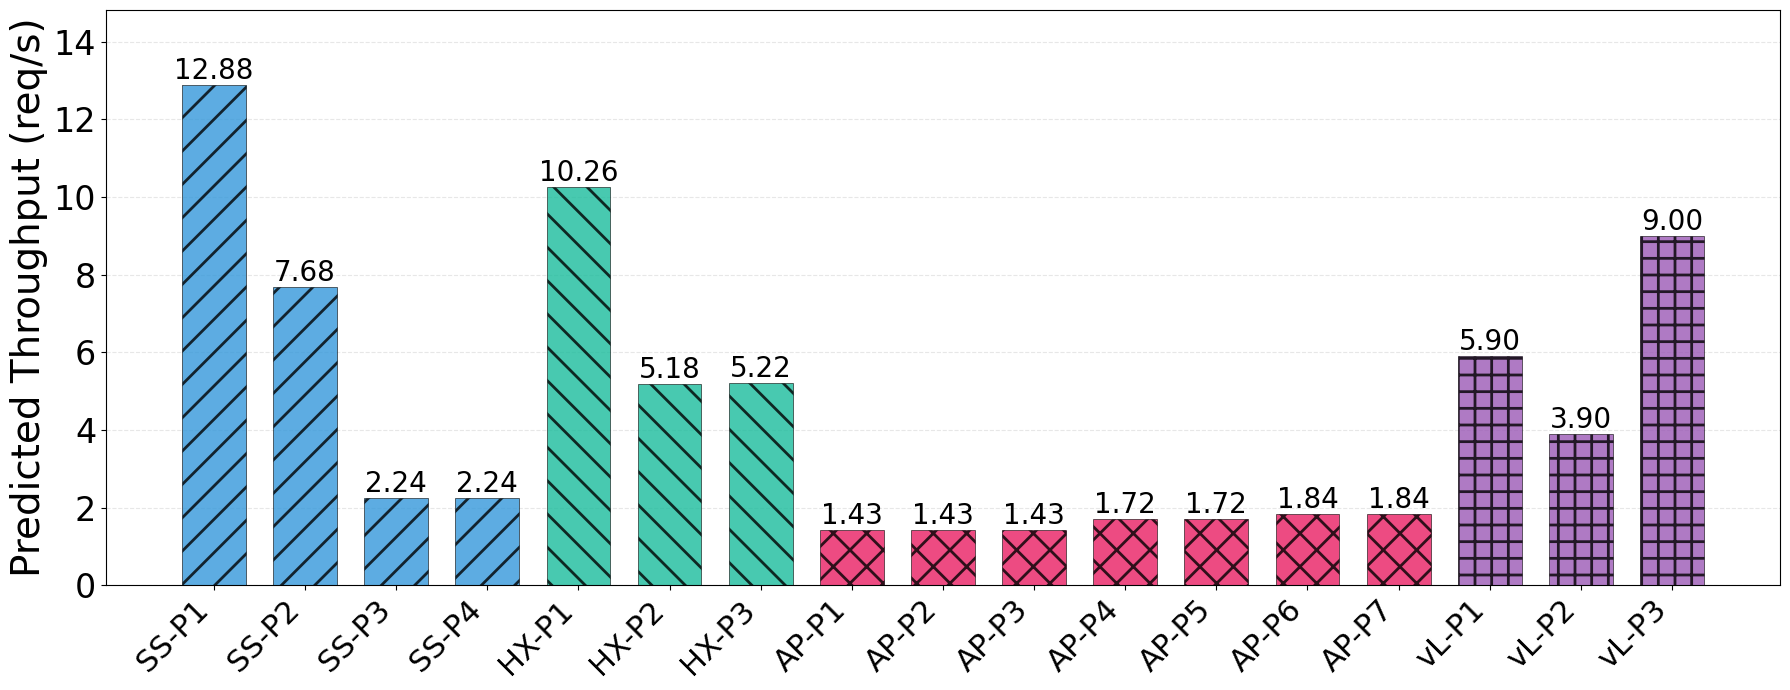

In [4]:
# === Per-Pipeline Bar Plot (Predicted only, or Predicted vs Measured) ===

labels = [p['label'] for p in all_pipelines]
predicted_vals = [p['predicted'] for p in all_pipelines]
systems = [p['system'] for p in all_pipelines]

x = np.arange(len(labels))

if has_measured:
    # Grouped bar: predicted vs measured
    measured_vals = [measured_map.get(l, 0) for l in labels]
    bar_width = 0.35
    fig, ax = plt.subplots(figsize=(20, 8))
    
    for i, (lbl, pred, meas, sys) in enumerate(zip(labels, predicted_vals, measured_vals, systems)):
        style = SYSTEM_STYLE[sys]
        # Predicted bar
        ax.bar(x[i] - bar_width/2, pred, bar_width, 
               color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
               hatch=style['hatch'])
        # Measured bar (solid, no hatch)
        if meas and meas > 0:
            ax.bar(x[i] + bar_width/2, meas, bar_width,
                   color=style['color'], alpha=0.5, edgecolor='black', linewidth=0.5)
    
    ax.set_ylabel('Throughput (req/s)', fontsize=FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONTSIZE - 6, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=FONTSIZE - 4)
    ax.set_ylim(0, max(max(predicted_vals), max(measured_vals)) * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add value labels
    for i, (pred, meas) in enumerate(zip(predicted_vals, measured_vals)):
        ax.text(x[i] - bar_width/2, pred, f'{pred:.2f}', ha='center', va='bottom', fontsize=FONTSIZE - 10)
        if meas and meas > 0:
            ax.text(x[i] + bar_width/2, meas, f'{meas:.2f}', ha='center', va='bottom', fontsize=FONTSIZE - 10)
    
    plt.tight_layout()
    plt.savefig('figures/pipeline_throughput_predicted_vs_measured.pdf', format='pdf', bbox_inches='tight')
    plt.show()

else:
    # Predicted only
    fig, ax = plt.subplots(figsize=(18, 7))
    
    for i, (lbl, val, sys) in enumerate(zip(labels, predicted_vals, systems)):
        style = SYSTEM_STYLE[sys]
        ax.bar(x[i], val, 0.7,
               color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
               hatch=style['hatch'])
    
    ax.set_ylabel('Predicted Throughput (req/s)', fontsize=FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONTSIZE - 6, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=FONTSIZE - 4)
    ax.set_ylim(0, max(predicted_vals) * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add value labels
    for i, val in enumerate(predicted_vals):
        ax.text(x[i], val, f'{val:.2f}', ha='center', va='bottom', fontsize=FONTSIZE - 8)
    
    plt.tight_layout()
    plt.savefig('figures/pipeline_throughput_predicted.pdf', format='pdf', bbox_inches='tight')
    plt.show()

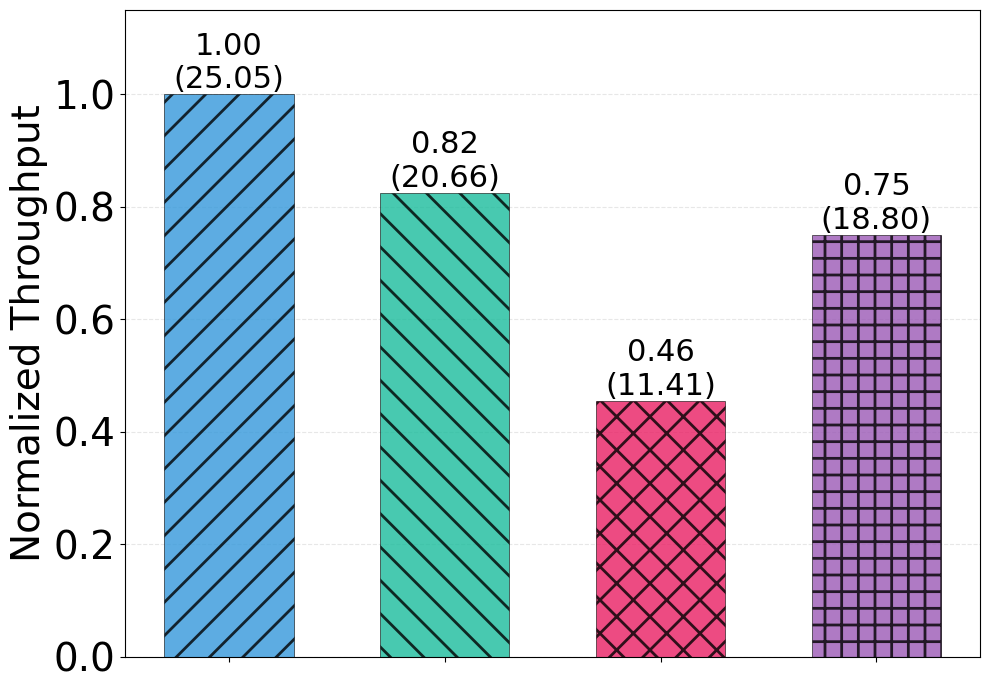

In [5]:
# === System-Level Total Throughput (Normalized by ShuntServe) ===

system_order_plot = ['ShuntServe', 'HexGen', 'AlpaServe', 'vLLM']
totals = [system_totals.get(s, 0) for s in system_order_plot]
shuntserve_total = system_totals.get('ShuntServe', 1)
normalized = [t / shuntserve_total for t in totals]

fig, ax = plt.subplots(figsize=(10, 7))

for i, sys in enumerate(system_order_plot):
    style = SYSTEM_STYLE[sys]
    ax.bar(i, normalized[i], 0.6,
           color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
           hatch=style['hatch'])

ax.set_ylabel('Normalized Throughput', fontsize=FONTSIZE)
ax.set_xticks(range(len(system_order_plot)))
ax.set_xticklabels([])
ax.tick_params(axis='y', labelsize=FONTSIZE)
ax.set_ylim(0, max(normalized) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels
for i, (val, raw) in enumerate(zip(normalized, totals)):
    ax.text(i, val, f'{val:.2f}\n({raw:.2f})',
            ha='center', va='bottom', fontsize=FONTSIZE - 6)

plt.tight_layout()
plt.savefig('figures/system_throughput_normalized.pdf', format='pdf', bbox_inches='tight')
plt.show()

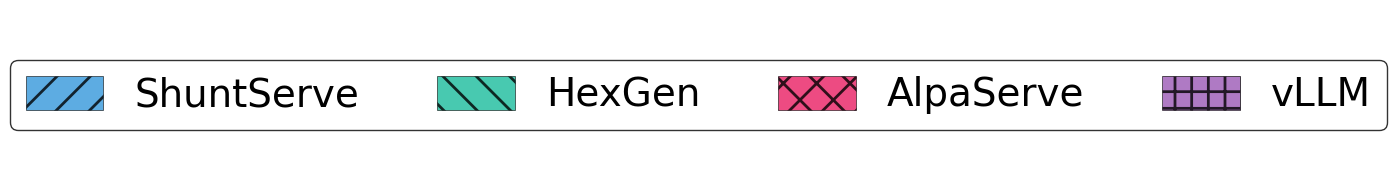

In [6]:
# === Legend (separate, for composing in paper) ===

fig, ax = plt.subplots(figsize=(12, 2))
ax.axis('off')

legend_patches = [
    mpatches.Patch(
        facecolor=SYSTEM_STYLE[s]['color'], label=s, alpha=0.8,
        edgecolor='black', linewidth=0.5, hatch=SYSTEM_STYLE[s]['hatch']
    )
    for s in system_order_plot
]

if has_measured:
    legend_patches.extend([
        mpatches.Patch(facecolor='white', edgecolor='black', linewidth=0.5,
                       hatch='///', label='Predicted', alpha=0.8),
        mpatches.Patch(facecolor='gray', edgecolor='black', linewidth=0.5,
                       label='Measured', alpha=0.5),
    ])

ax.legend(handles=legend_patches, loc='center',
          ncol=len(legend_patches), fontsize=FONTSIZE,
          frameon=True, handlelength=2, handleheight=1, edgecolor='black')

plt.tight_layout()
plt.savefig('figures/throughput_legend.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Ranking Visualizations
Predicted ranking shown immediately. Measured overlay added when data arrives.

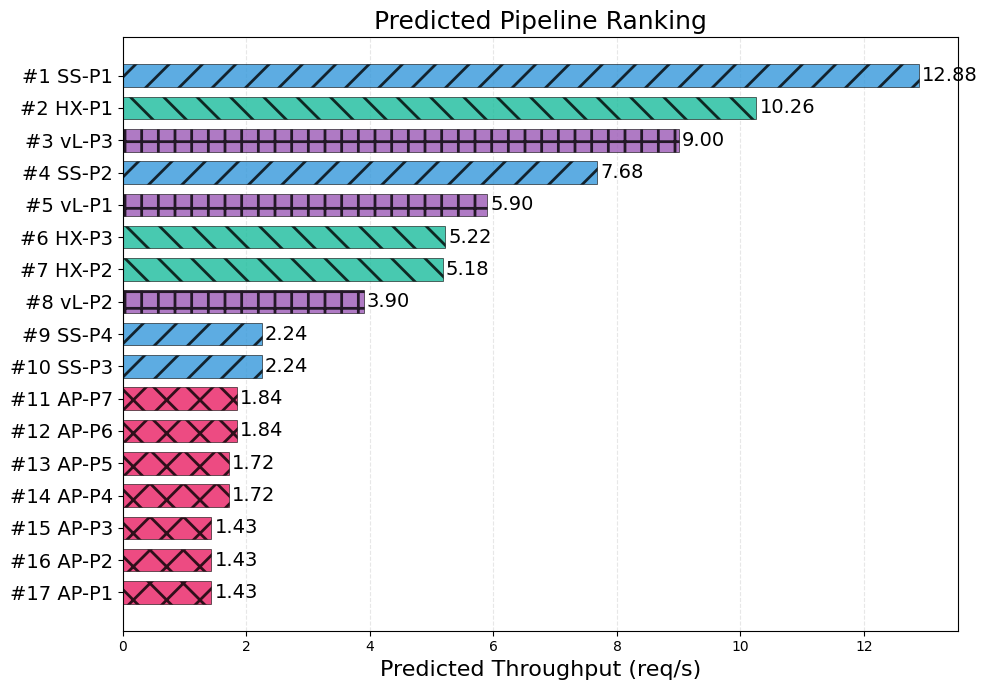

In [7]:
# === 1. Scatter Plot: Predicted vs Measured ===
# Predicted-only: show predicted values sorted on x-axis with rank labels
# With measured: scatter with diagonal line

from scipy.stats import spearmanr, kendalltau

pred_sorted = sorted(zip(predicted_vals, labels, systems), reverse=True)
sorted_vals = [v for v, _, _ in pred_sorted]
sorted_labels = [l for _, l, _ in pred_sorted]
sorted_systems = [s for _, _, s in pred_sorted]

if has_measured:
    meas_arr = np.array([measured_map.get(l, 0) for l in labels])
    valid = meas_arr > 0
    p, m = np.array(predicted_vals)[valid], meas_arr[valid]
    vlabels = np.array(labels)[valid]
    vsystems = np.array(systems)[valid]
    rho, _ = spearmanr(p, m)
    tau, _ = kendalltau(p, m)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    for i in range(len(p)):
        style = SYSTEM_STYLE[vsystems[i]]
        ax.scatter(p[i], m[i], c=style['color'], s=150, edgecolors='black', linewidth=1, zorder=5)
        ax.annotate(vlabels[i], (p[i], m[i]), textcoords='offset points', xytext=(8, 8), fontsize=12)
    lo = min(p.min(), m.min()) * 0.8
    hi = max(p.max(), m.max()) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.3, label='y=x')
    ax.set_xlabel('Predicted Throughput (req/s)', fontsize=18)
    ax.set_ylabel('Measured Throughput (req/s)', fontsize=18)
    ax.set_title(f'Spearman ρ={rho:.3f}, Kendall τ={tau:.3f}', fontsize=18)
    ax.tick_params(labelsize=14)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    # Predicted-only: horizontal bar chart sorted by rank
    fig, ax = plt.subplots(figsize=(10, 7))
    y = np.arange(len(sorted_vals))
    for i, (val, lbl, sys) in enumerate(zip(sorted_vals, sorted_labels, sorted_systems)):
        style = SYSTEM_STYLE[sys]
        ax.barh(i, val, 0.7, color=style['color'], alpha=0.8,
                edgecolor='black', linewidth=0.5, hatch=style['hatch'])
        ax.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=14)
    ax.set_yticks(y)
    ax.set_yticklabels([f'#{i+1} {l}' for i, l in enumerate(sorted_labels)], fontsize=14)
    ax.invert_yaxis()
    ax.set_xlabel('Predicted Throughput (req/s)', fontsize=16)
    ax.set_title('Predicted Pipeline Ranking', fontsize=18)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

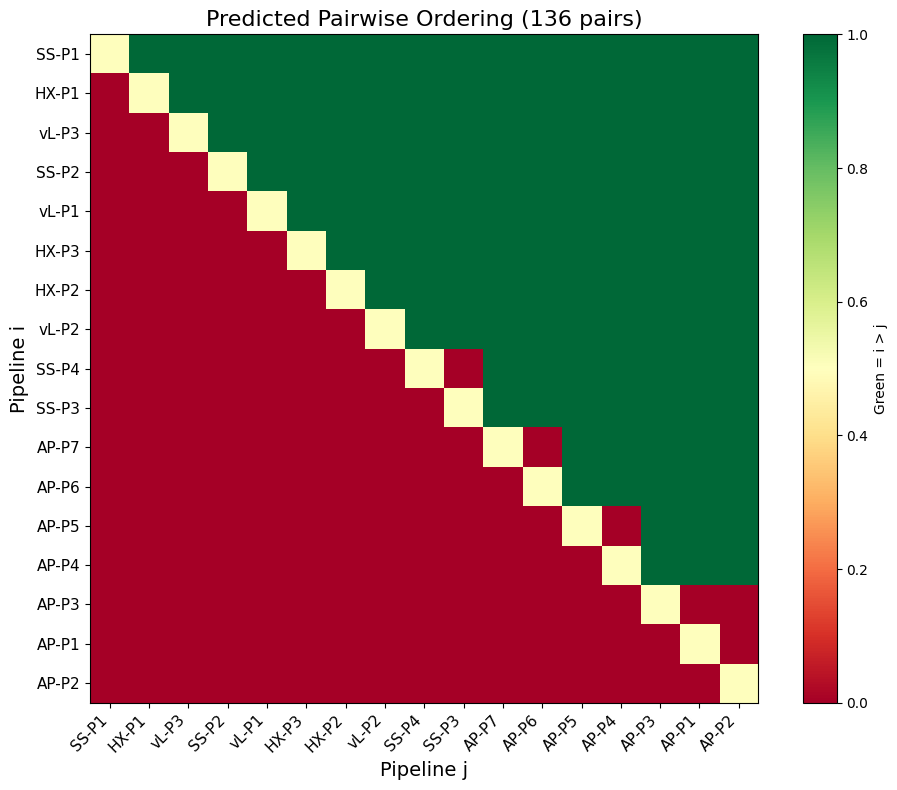

Total pairwise comparisons: 136
Will verify concordance when measured data arrives


In [8]:
# === 2. Pairwise Concordance ===

if has_measured:
    meas_arr = np.array([measured_map.get(l, 0) for l in labels])
    valid = meas_arr > 0
    p, m = np.array(predicted_vals)[valid], meas_arr[valid]
    vlabels = np.array(labels)[valid]
    n = len(p)
    
    concordant = discordant = tied = 0
    disc_pairs = []
    for i in range(n):
        for j in range(i+1, n):
            po = np.sign(p[i] - p[j])
            mo = np.sign(m[i] - m[j])
            if po == mo: concordant += 1
            elif po == 0 or mo == 0: tied += 1
            else:
                discordant += 1
                disc_pairs.append((vlabels[i], vlabels[j]))
    
    total = concordant + discordant + tied
    print(f'Pairwise Concordance: {concordant}/{total} ({concordant/total*100:.1f}%)')
    if disc_pairs:
        print(f'Discordant pairs: {disc_pairs}')
    
    # Heatmap
    matrix = np.full((n, n), 0.5)
    for i in range(n):
        for j in range(n):
            if i != j:
                matrix[i][j] = 1.0 if np.sign(p[i]-p[j]) == np.sign(m[i]-m[j]) else 0.0
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(vlabels, rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(vlabels, fontsize=12)
    ax.set_title(f'Pairwise Concordance ({concordant}/{total})', fontsize=16)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    # Predicted-only: show predicted pairwise comparison matrix
    n = len(predicted_vals)
    pred_arr = np.array(predicted_vals)
    
    # Sort by predicted rank
    rank_idx = np.argsort(pred_arr)[::-1]  # descending
    ranked_labels = [labels[i] for i in rank_idx]
    ranked_vals = pred_arr[rank_idx]
    
    # Matrix: cell (i,j) = predicted_i > predicted_j ?
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j: matrix[i][j] = 0.5
            elif ranked_vals[i] > ranked_vals[j]: matrix[i][j] = 1.0
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(ranked_labels, rotation=45, ha='right', fontsize=11)
    ax.set_yticklabels(ranked_labels, fontsize=11)
    ax.set_title(f'Predicted Pairwise Ordering ({n*(n-1)//2} pairs)', fontsize=16)
    ax.set_xlabel('Pipeline j', fontsize=14)
    ax.set_ylabel('Pipeline i', fontsize=14)
    plt.colorbar(im, ax=ax, label='Green = i > j')
    plt.tight_layout()
    plt.show()
    print(f'Total pairwise comparisons: {n*(n-1)//2}')
    print(f'Will verify concordance when measured data arrives')

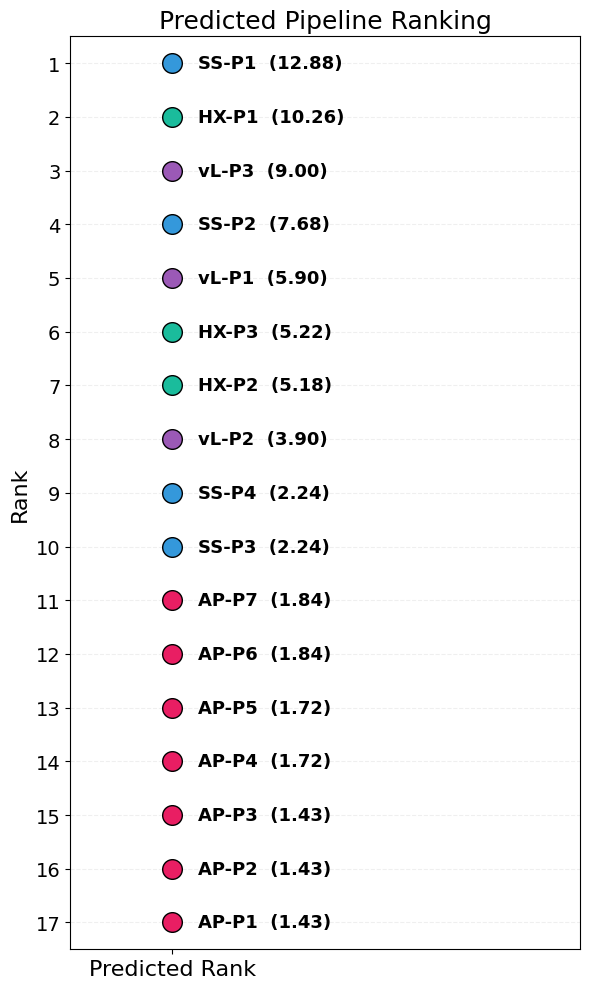

Measured rank column will appear when data arrives


In [9]:
# === 3. Bump Chart: Predicted Rank vs Measured Rank ===

if has_measured:
    meas_arr = np.array([measured_map.get(l, 0) for l in labels])
    valid = meas_arr > 0
    p, m = np.array(predicted_vals)[valid], meas_arr[valid]
    vlabels = np.array(labels)[valid]
    vsystems = np.array(systems)[valid]
    n = len(p)
    
    pred_rank = n - p.argsort().argsort()
    meas_rank = n - m.argsort().argsort()
    
    fig, ax = plt.subplots(figsize=(8, 10))
    for i in range(n):
        style = SYSTEM_STYLE[vsystems[i]]
        ax.plot([0, 1], [pred_rank[i], meas_rank[i]], '-o',
                color=style['color'], linewidth=2, markersize=10, markeredgecolor='black')
        ax.text(-0.05, pred_rank[i], vlabels[i], ha='right', va='center',
                fontsize=12, color=style['color'], fontweight='bold')
        ax.text(1.05, meas_rank[i], vlabels[i], ha='left', va='center',
                fontsize=12, color=style['color'], fontweight='bold')
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(n + 0.5, 0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Predicted Rank', 'Measured Rank'], fontsize=16)
    ax.set_yticks(range(1, n+1))
    ax.set_ylabel('Rank', fontsize=16)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_title('Ranking Comparison', fontsize=18)
    plt.tight_layout()
    plt.show()
else:
    # Predicted-only: single column rank
    pred_sorted = sorted(zip(predicted_vals, labels, systems), reverse=True)
    n = len(pred_sorted)
    
    fig, ax = plt.subplots(figsize=(6, 10))
    for rank, (val, lbl, sys) in enumerate(pred_sorted, 1):
        style = SYSTEM_STYLE[sys]
        ax.scatter(0, rank, c=style['color'], s=200, edgecolors='black', linewidth=1, zorder=5)
        ax.text(0.05, rank, f'{lbl}  ({val:.2f})', va='center', fontsize=13, fontweight='bold')
    
    ax.set_xlim(-0.2, 0.8)
    ax.set_ylim(n + 0.5, 0.5)
    ax.set_xticks([0])
    ax.set_xticklabels(['Predicted Rank'], fontsize=16)
    ax.set_yticks(range(1, n+1))
    ax.set_ylabel('Rank', fontsize=16)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_title('Predicted Pipeline Ranking', fontsize=18)
    plt.tight_layout()
    plt.show()
    print('Measured rank column will appear when data arrives')